# Data Science and Machine Learning Lab
## Lab 04 - Tree-based classification

In this laboratory you will learn about classification problems and how they can be approached using a category of tree-based models. In particular, you will use a decision tree from scikit-learn. You will see it in action with different datasets and understand its points of strength and weaknesses. Then, you will implement your own version of a random forest, starting from scikit-learn's decision trees.

## 1. Preliminary steps

### 1.1 Useful libraries
The main library you will need for this laboratory is scikit-learn. You should already have it from previous labs. If not, you can install it using pip.

### 1.2 Datasets
For this laboratory, you will both use datasets already available from scikit-learn, and a synthetic dataset you can download from GitHub.

#### 1.2.1 Wine dataset
The Wine dataset is a famous dataset available on the UCI ML repository. The data is the result of a chemical analysis of wines grown in the same region in Italy, but derived from three different cultivars. The analysis determined the quantities of 13 constituents found in each of the three types of wines. From these 13 constituents (features), your goal is to predict the target class (the cultivars).

You can either download the dataset from UCI, or you can get it directly from scikit-learn.

In [1]:
from sklearn.datasets import load_wine
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import plot_tree, export_graphviz
import matplotlib.pyplot as plt
import pydot
from IPython.display import Image
import os
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV, ParameterGrid, KFold
import numpy as np

graphviz_bin = r"C:\Program Files\Graphviz\bin"
if os.path.exists(graphviz_bin) and graphviz_bin not in os.environ.get("PATH", ""):
    os.environ["PATH"] = graphviz_bin + os.pathsep + os.environ.get("PATH", "")

In [3]:
dataset = load_wine()
X = dataset["data"]
y = dataset["target"]
feature_names = dataset["feature_names"]
wine_df = pd.DataFrame(X, columns=feature_names)
wine_df["target"] = y
wine_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


#### 1.2.2 Synthetic 2d dataset
This is a very simple 2d dataset that will help you understand some of the limitations of decision trees. It contains 2 synthetic features, each ranging from 0 to 10, and a target class (0 or 1).

You can download it from the following link as a CSV file:
https://raw.githubusercontent.com/dbdmg/data-science-lab/master/datasets/2d-synthetic.csv

In [4]:
!wget https://raw.githubusercontent.com/dbdmg/data-science-lab/master/datasets/2d-synthetic.csv


--2026-05-07 12:32:28--  https://raw.githubusercontent.com/dbdmg/data-science-lab/master/datasets/2d-synthetic.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 19259 (19K) [text/plain]
Saving to: '2d-synthetic.csv.1'

     0K .......... ........                                   100% 7.30M=0.003s

2026-05-07 12:32:29 (7.30 MB/s) - '2d-synthetic.csv.1' saved [19259/19259]



In [5]:
synthetic_df = pd.read_csv("2d-synthetic.csv")
synthetic_df.head()

,x0,x1,label
0,9.833469,0.319565,0
1,1.801045,8.705072,0
2,4.423918,3.488906,1
3,0.280730,2.689037,1
4,5.999494,9.167512,0


#### 1.2.3 MNIST
You have already met MNIST in the first lab. In that occasion, we used a dataset of 10,000 digits: that was the MNIST test set. A training set of 60,000 digits is also available.

You can download the entire MNIST dataset either from the original source, or you can use sklearn's `fetch_openml` function.

Info: While very convenient, it might happen (if no caching occurs) that `fetch_openml` will need to download the dataset multiple times (i.e. at each execution).

## 2. Exercises

Note that exercises marked with (*) are optional, you should focus on completing the other ones first.

## 2.1 Wine classification
In this exercise, you will use sklearn's `DecisionTreeClassifier` to build a decision tree for the wine dataset. You can read more about this class on the official documentation.

### Task 2.1.1
Load the dataset from sklearn, as described in Subsec. 1.2.1. Then, based on your `X` and `y`, answer the following questions:
- How many records are available?
- Are there missing values?
- How many elements does each class contain?

In [6]:
print(f"Records: {wine_df.shape[0]}")
print(f"Missing values: {int(wine_df.isna().sum().sum())}")

Records: 178
Missing values: 0


In [7]:
print(pd.Series(y).value_counts().sort_index())

0    59
1    71
2    48
Name: count, dtype: int64


### Task 2.1.2
Create a `DecisionTreeClassifier` object with the default configuration (i.e. without passing any parameters to the constructor). Train the classifier using your `X` and `y`.

In [8]:
# Your code here
tree = DecisionTreeClassifier()
tree.fit(X, y)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### Task 2.1.3
Now that you have created a tree, you can visualize it. Sklearn offers two functions to visualize decision trees.
- `plot_tree()`: plots the tree in a matplotlib-based, interactive window.
- `export_graphviz()`: exports the tree as a DOT file.

After you successfully plotted a tree, take a closer look at the result and draw some conclusions. In particular:
- What information is contained in each node?
- Take a closer look at the leaf nodes. Based on what you know about overfitting, what can you learn from these nodes?

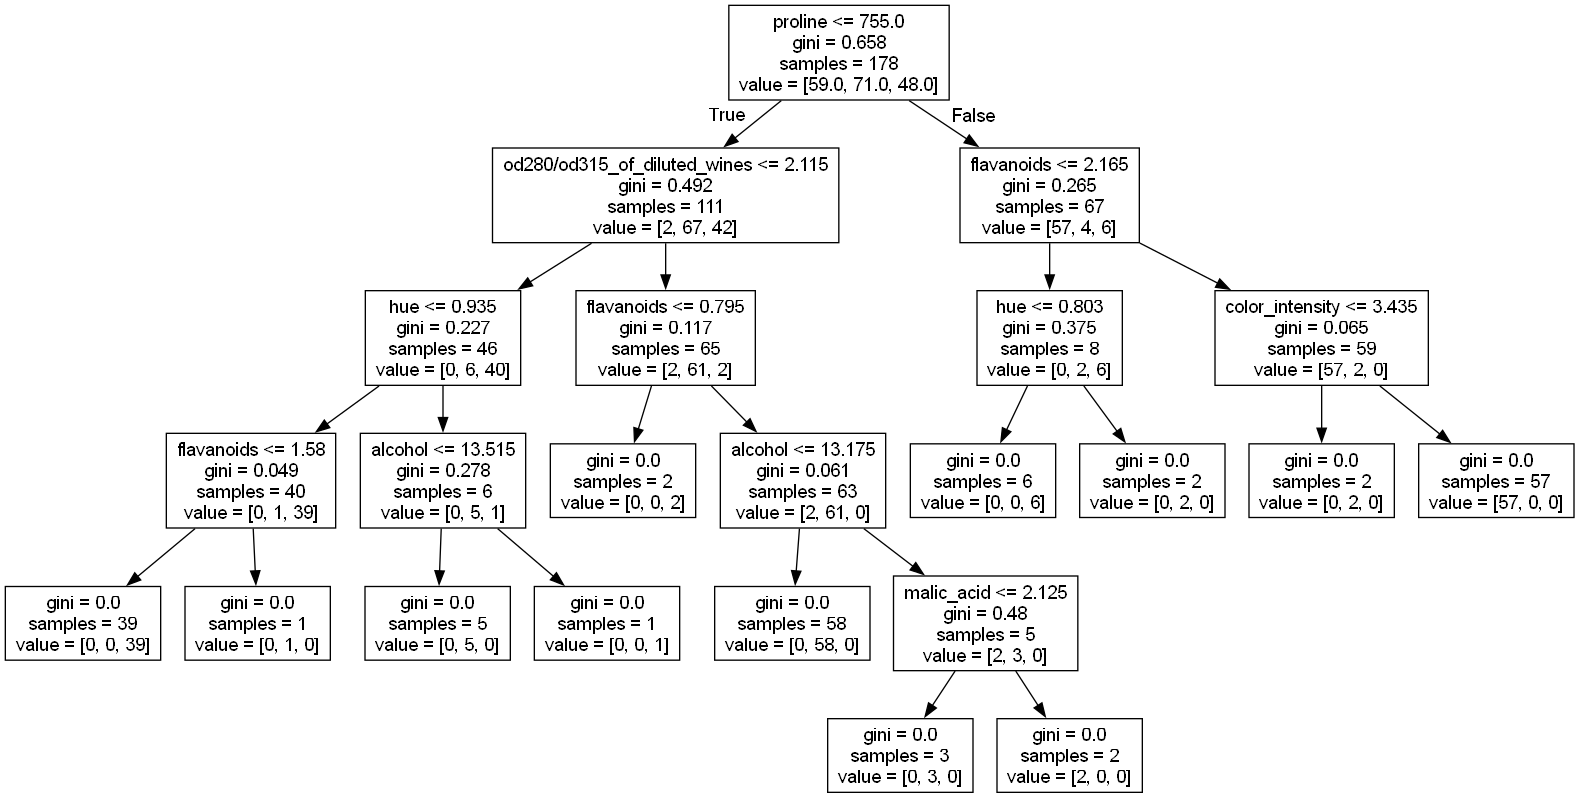

In [9]:
# Your code here
dot_code = export_graphviz(tree, feature_names=feature_names)
graph = pydot.graph_from_dot_data(dot_code)
Image(graph[0].create_png())

### Task 2.1.4
Given the dataset `X`, get the predictions of the classifier by calling `predict()`. Then, use `accuracy_score()` (from `sklearn.metrics`) to compute the accuracy between `y_true` and `y_pred`.

Questions:
- What result do you get?
- Does this result seem particularly high/low? Why do you think that is?

In [10]:
# Your code here
accuracy = accuracy_score(y, tree.predict(X))
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 1.0000


### Task 2.1.5
Now, split your dataset into a training set and a test set. Use an 80/20 train/test split.

If used correctly, you will get 4 arrays: `X_train`, `X_test`, `y_train`, `y_test`.

In [11]:
# Your code here
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Task 2.1.6
Train a new model using (`X_train`, `y_train`). Then, compute the accuracy with (`X_test`, `y_test`).

Questions:
- How does this value compare to the previously computed one?
- Is this a more reasonable value? Why?

You can also compute other metrics (e.g. precision, recall, F1 score) and/or use `classification_report`.

In [12]:
# Your code here
tree.fit(x_train, y_train)
accuracy = accuracy_score(y_test, tree.predict(x_test))
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9444


### Task 2.1.7
Perform a grid search over decision tree hyperparameters.

Steps:
1. Identify parameters that might affect performance (e.g. `max_depth`, `splitter`, and others).
2. Define candidate values for each parameter.
3. Use `ParameterGrid` to generate all configurations.
4. For each configuration, train on training data and compute test accuracy.
5. Select the configuration with highest accuracy.

Info: You can pass a configuration dictionary to `DecisionTreeClassifier` with `DecisionTreeClassifier(**config)`.

Info: Hyperparameters are set before training. Model parameters are learned during training.

In [13]:
# Your code here
parameterGrid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}
parameterList = list(ParameterGrid(parameterGrid))
best_accuracy = [0, None]
for params in parameterList:
    tree = DecisionTreeClassifier(**params)
    tree.fit(x_train, y_train)
    accuracy = accuracy_score(y_test, tree.predict(x_test))
    if accuracy > best_accuracy[0]:
        best_accuracy[0] = accuracy
        best_accuracy[1] = params

print(f"Best Accuracy: {best_accuracy[0]:.4f}")
print(f"Best Parameters: {best_accuracy[1]}")

Best Accuracy: 0.9444
Best Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


### Task 2.1.8
Repeat model selection with k-fold cross-validation to avoid overfitting on the test set.

Use the split roles:
- Training set: used to create the model
- Validation set: used to assess each hyperparameter configuration
- Test set: used only for final evaluation

Use `KFold` from sklearn for k-fold cross-validation. For each fold, train on fold-train and validate on fold-valid, aggregate results, select the best configuration, then evaluate once on the held-out test set.

In [14]:
# Your code here
import numpy as np
KFolds = KFold(n_splits=5).split(x_train, y_train)
performances = []
for fold in KFolds:
    x_train_fold, y_train_fold = x_train[fold[0]], y_train[fold[0]]
    x_val_fold, y_val_fold = x_train[fold[1]], y_train[fold[1]]
    tree = DecisionTreeClassifier(**best_accuracy[1])
    tree.fit(x_train_fold, y_train_fold)
    accuracy = accuracy_score(y_val_fold, tree.predict(x_val_fold))
    performances.append([x_train_fold, y_train_fold, accuracy])
print("Fold Performances:")

for performance in performances:
    print(f"Accuracy = {performance[2]}")
    best_fold = performances[np.argmax([acc for _, _, acc in performances])]
print(f"Best Fold: {np.argmax([acc for _, _, acc in performances])} with Accuracy = {best_fold[2]:.4f}")

best_tree =  DecisionTreeClassifier(**best_accuracy[1])
best_tree.fit(best_fold[0], best_fold[1])
accuracy = accuracy_score(y_test, best_tree.predict(x_test))
print(f"Test Accuracy of Best Fold: {accuracy:.4f}")


Fold Performances:
Accuracy = 0.9310344827586207
Accuracy = 0.9310344827586207
Accuracy = 0.8928571428571429
Accuracy = 0.9285714285714286
Accuracy = 0.8928571428571429
Best Fold: 0 with Accuracy = 0.9310
Test Accuracy of Best Fold: 0.9444


### Task 2.1.9 (*)
Given a decision tree, compute feature importances from impurity decrease at each split.

Definitions for a node P:
- i_P: impurity of parent node
- i_L, i_R: impurity of left and right children
- |P|, |L|, |R|: cardinalities (number of samples)
- N: total number of observations

Compute:
I(P) = (|P|/N) i_P - (|L|/N) i_L - (|R|/N) i_R

Then compute each feature importance by summing importances of nodes that split on that feature, and normalize so importances sum to 1.

Note: sklearn already computes feature importances in `clf.feature_importances_`.

In [99]:
node_indicator = tree.decision_path(x_train)
def compute_impurity(y_node, y_child_l, y_child_r):
    # Helper to calculate Gini for a single set of labels
    def gini(y):
        if len(y) == 0: return 0
        # Get counts of each class (e.g., [10, 5] if 10 of class 0 and 5 of class 1)
        _, counts = np.unique(y, return_counts=True)
        probs = counts / len(y)
        return 1 - np.sum(probs ** 2)

    g_parent = gini(y_node)
    g_left = gini(y_child_l)
    g_right = gini(y_child_r)
    
    # Weight the children by how many samples they contain
    n_total = len(y_node)
    n_l = len(y_child_l)
    n_r = len(y_child_r)
    
    # Information Gain = Parent Impurity - Weighted Children Impurity
    gain = g_parent - (n_l / n_total * g_left + n_r / n_total * g_right)
    return gain

def prepare_nodes(node_id):
    # 1. Get indices for parent and children
    idx_p = node_indicator[:, node_id].nonzero()[0]
    idx_l = node_indicator[:, tree.tree_.children_left[node_id]].nonzero()[0]
    idx_r = node_indicator[:, tree.tree_.children_right[node_id]].nonzero()[0]
    
    # 2. Extract the actual labels (y) for these samples
    # We use these to see the class distribution
    y_p = y_train[idx_p]
    y_l = y_train[idx_l]
    y_r = y_train[idx_r]
    
    return compute_impurity(y_p, y_l, y_r)

# Example usage
gain = prepare_nodes(8)
print(f"Impurity reduction at root: {gain}")

Impurity reduction at root: 0.2222222222222222


## 2.2 Synthetic dataset
In this exercise, apply some of the steps from Exercise 1 on a different dataset to highlight weaknesses of decision trees.

### Task 2.2.1
Load the synthetic dataset you downloaded. Plot it with matplotlib `scatter()` on a 2D plane and color points by class label.

Question: How do you expect a decision tree to approach data distributed in this way?

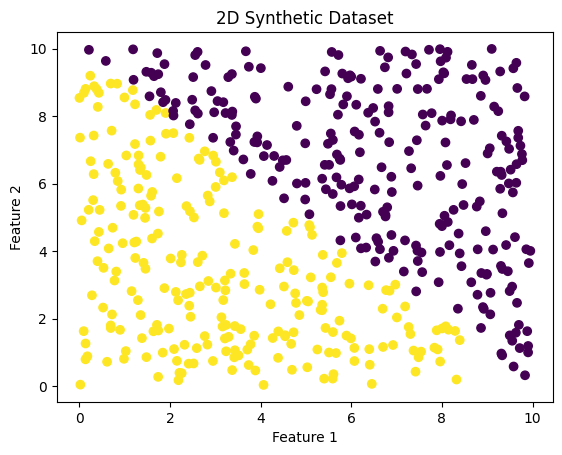

In [119]:
# Your code here
synth_df = pd.read_csv("2d-synthetic.csv")
x = synth_df.iloc[:, :2]
y = synth_df.iloc[:, 2]
plt.scatter(x.iloc[:, 0], x.iloc[:, 1], c=y)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("2D Synthetic Dataset")
plt.show()

### Task 2.2.2
Build a default decision tree using the entire dataset, then visualize the learned model.

Question: What is the tree learning, and why?

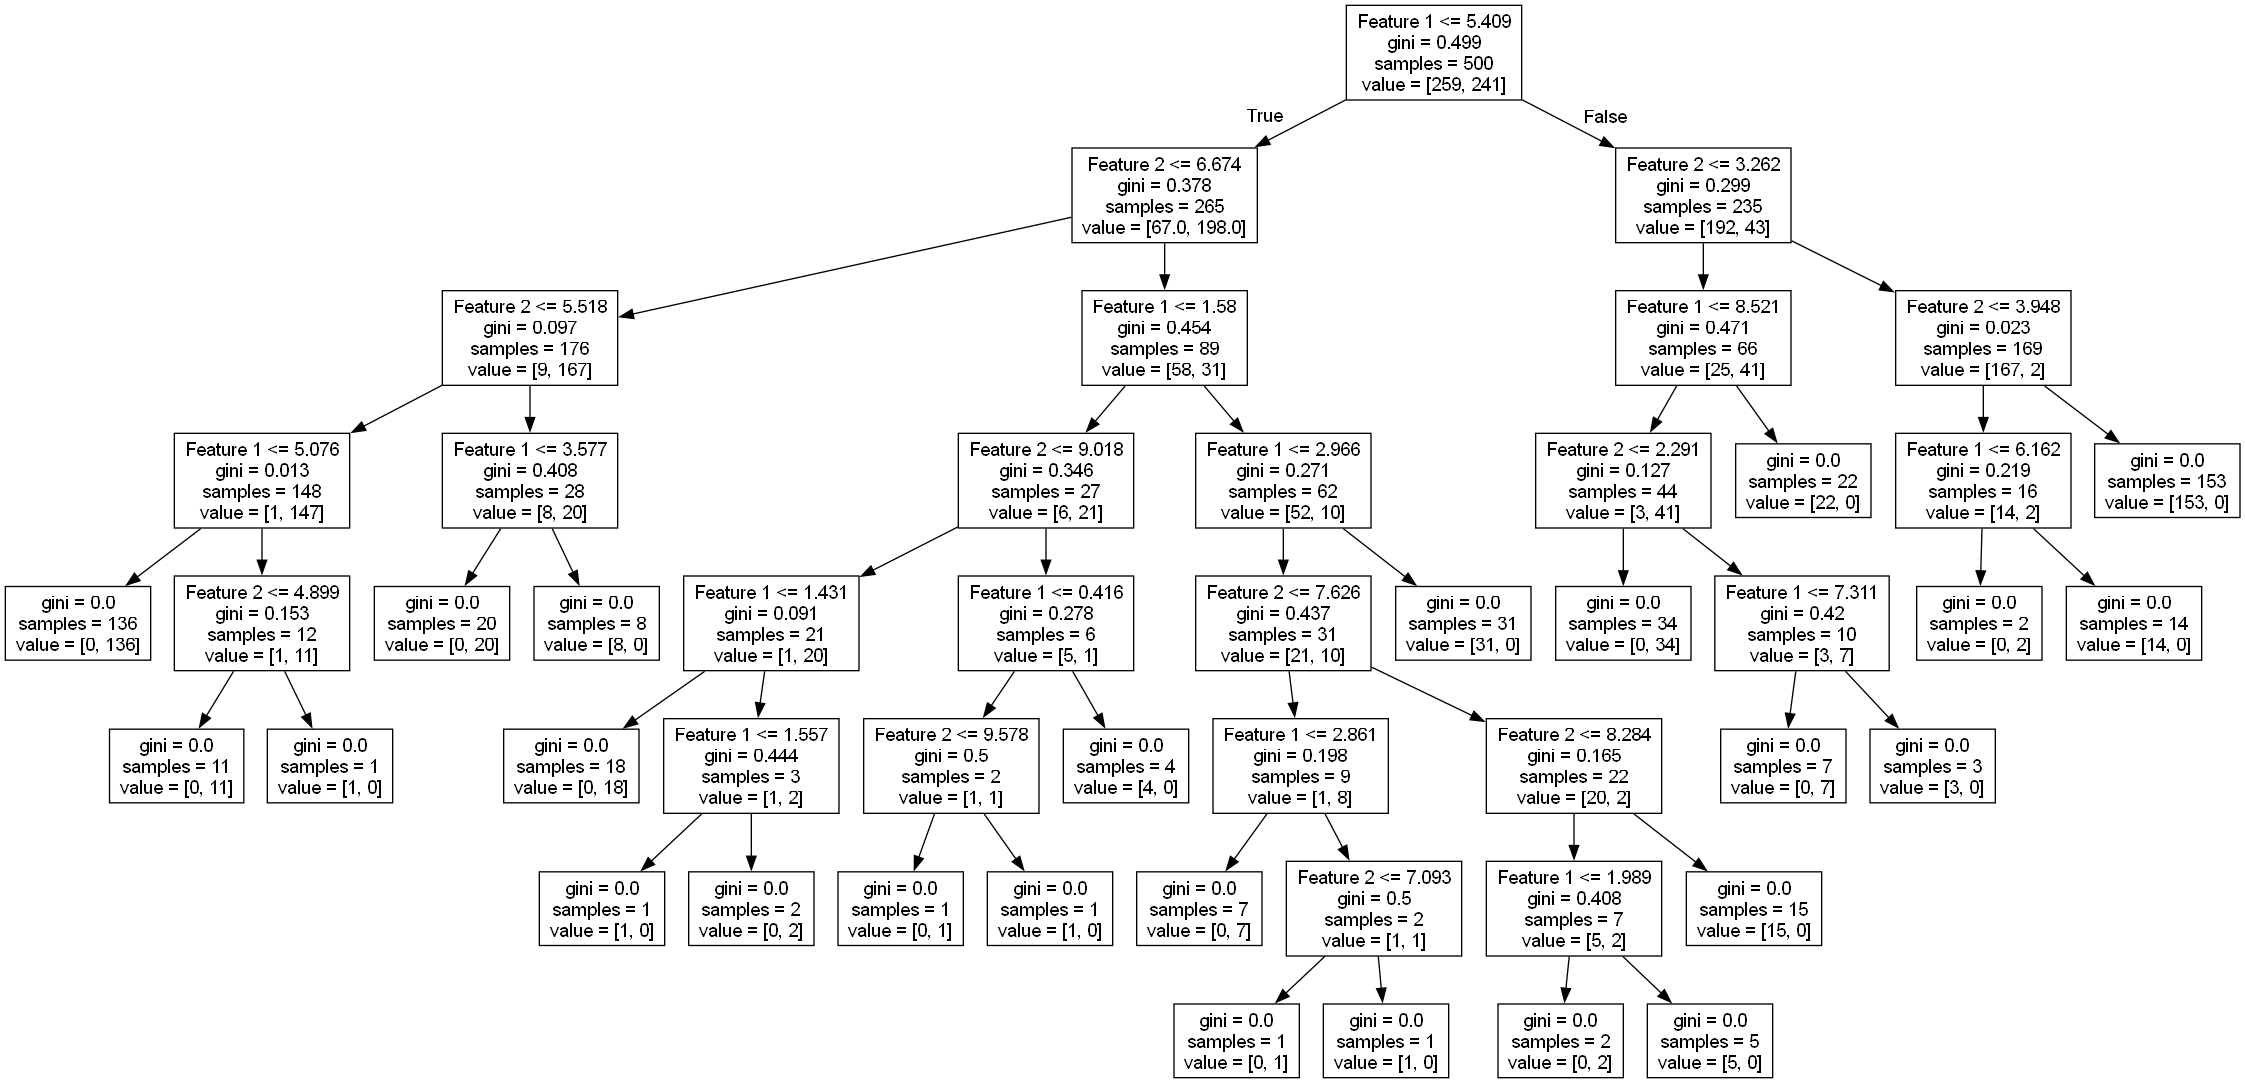

In [136]:
# Your code here
tree_synth = DecisionTreeClassifier()
tree_synth.fit(x, y)
graph = export_graphviz(tree_synth, feature_names=["Feature 1", "Feature 2"])
graph_img = pydot.graph_from_dot_data(graph)[0]
Image(graph_img.create_png())

### Task 2.2.3 (*)
Identify a preprocessing step that would make the decision tree correctly approach this problem.

0      9.833469
1      1.801045
2      4.423918
3      0.280730
4      5.999494
         ...   
495    4.995458
496    6.636632
497    6.373259
498    1.230331
499    6.070298
Name: x0, Length: 500, dtype: float64

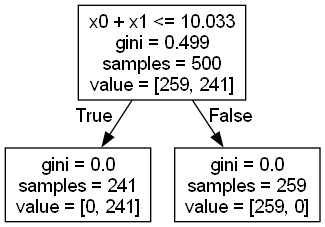

In [133]:
# Your code here
new_x = np.array(x.iloc[:, 1] + x.iloc[:, 0]).reshape(-1, 1)
tree_synth.fit(new_x, y)
accuracy = accuracy_score(y, tree_synth.predict(new_x))
accuracy
dot_code = export_graphviz(tree_synth, feature_names=["x0 + x1"])
graph = pydot.graph_from_dot_data(dot_code)
Image(graph[0].create_png())

### Task 2.2.4 (*)
Use `clf.tree_.feature` and `clf.tree_.threshold` to plot the decision boundaries learned by the decision tree on top of the dataset.

You can use matplotlib `axvline` and `axhline` to draw vertical/horizontal thresholds.

f:\Practices\MyRandomMLPractices\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


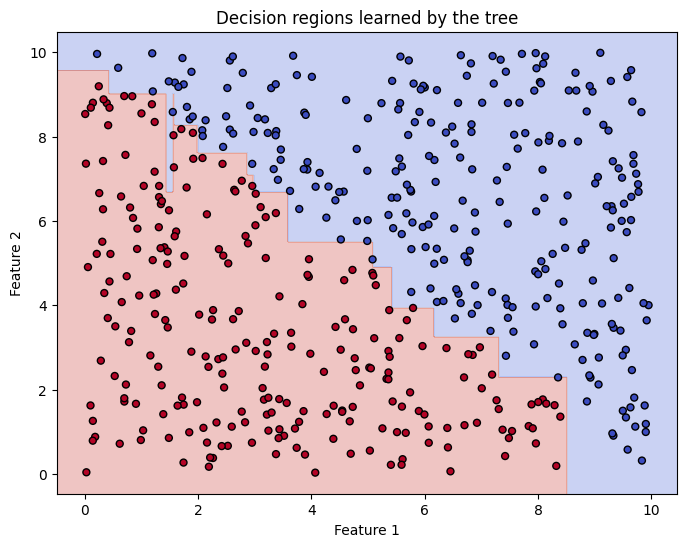

In [138]:
import numpy as np
import matplotlib.pyplot as plt

X_plot = x.to_numpy()

x_min, x_max = X_plot[:, 0].min() - 0.5, X_plot[:, 0].max() + 0.5
y_min, y_max = X_plot[:, 1].min() - 0.5, X_plot[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)

grid = np.c_[xx.ravel(), yy.ravel()]
Z = tree_synth.predict(grid).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
plt.scatter(X_plot[:, 0], X_plot[:, 1], c=y, cmap="coolwarm", edgecolors="k", s=25)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Decision regions learned by the tree")
plt.show()

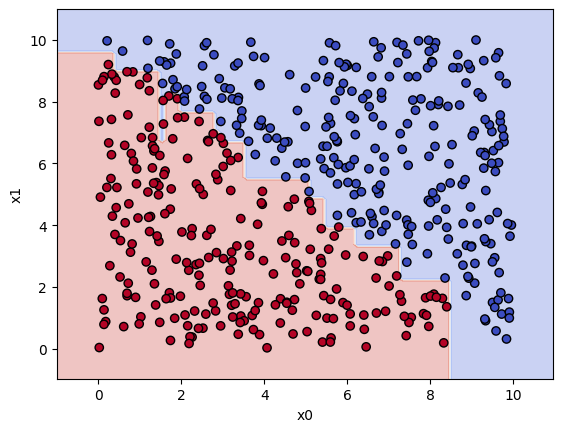

In [139]:
from sklearn.inspection import DecisionBoundaryDisplay
import matplotlib.pyplot as plt

DecisionBoundaryDisplay.from_estimator(
    tree_synth,
    x,
    response_method="predict",
    cmap="coolwarm",
    alpha=0.3
)
plt.scatter(x.iloc[:, 0], x.iloc[:, 1], c=y, cmap="coolwarm", edgecolors="k")
plt.show()

## 2.3 Random forest
In this exercise, you will implement your own version of a random forest using scikit-learn decision trees, then assess performance on MNIST.

### Task 2.3.1
Load MNIST into memory. Divide the 70,000 digits into a training set (60,000) and a test set (10,000).

In [2]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml("mnist_784")
X = mnist["data"]
y = mnist["target"]
mnist_df = pd.DataFrame(X)
mnist_df["target"] = y
mnist_df.head()

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784,target
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9


Info: While very convenient, it might happen (if no caching occurs) that `fetch_openml` will need to download the dataset multiple times (i.e. at each execution).

In [3]:
print(mnist_df.isna().sum())

pixel1      0
pixel2      0
pixel3      0
pixel4      0
pixel5      0
           ..
pixel781    0
pixel782    0
pixel783    0
pixel784    0
target      0
Length: 785, dtype: int64


In [4]:
mnist_df.describe(), mnist_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Columns: 785 entries, pixel1 to target
dtypes: category(1), int64(784)
memory usage: 418.8 MB


(        pixel1   pixel2   pixel3   pixel4   pixel5   pixel6   pixel7   pixel8  \
 count  70000.0  70000.0  70000.0  70000.0  70000.0  70000.0  70000.0  70000.0   
 mean       0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
 std        0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
 min        0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
 25%        0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
 50%        0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
 75%        0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
 max        0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
 
         pixel9  pixel10  ...      pixel775      pixel776      pixel777  \
 count  70000.0  70000.0  ...  70000.000000  70000.000000  70000.000000   
 mean       0.0      0.0  ...      0.197414      0.099543      0.046629   
 std        0.0      0.0  ...      

### Task 2.3.2
Train a single decision tree (default parameters) on the training set, then compute its accuracy on the test set.

In [5]:
# Your code here
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
mnist_tree = DecisionTreeClassifier()
mnist_tree.fit(x_train, y_train)
accuracy = accuracy_score(y_test, mnist_tree.predict(x_test))
print(f"MNIST Test Accuracy: {accuracy:.4f}")

MNIST Test Accuracy: 0.8718


### Task 2.3.3
Implement your own `MyRandomForestClassifier` with:
- `__init__(self, n_estimators, max_features)`
- `fit(self, X, y)`
- `predict(self, X)`

Random forest notes from the lab:
- Each tree is trained on N samples extracted with replacement from N dataset points (bootstrap).
- About 63.2% of unique samples are used in each tree.
- At each split, use a random subset of features controlled by `max_features`.
- Prediction is done by majority voting across trees.

In [6]:
# Your code here
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from scipy import stats

class MyRandomForestClassifier:
    def __init__(self, n_estimators=10, max_features="sqrt"):
        self.n_estimators = n_estimators
        self.max_features = max_features
        self.trees = []

    def fit(self, X, y):
        # Ensure inputs are numpy arrays for consistent indexing
        X = np.asarray(X)
        y = np.asarray(y)
        n_samples, n_features = X.shape
        self.trees = []

        for _ in range(self.n_estimators):
            # 1. Bootstrap Sampling: Select rows with replacement
            # This is the "Bagging" part of Random Forest
            indices = np.random.choice(n_samples, n_samples, replace=True)
            X_bootstrap = X[indices]
            y_bootstrap = y[indices]

            # 2. Decision Tree with Feature Randomness
            # We pass max_features to the tree so it selects a random 
            # subset of features at every single split (node)
            tree = DecisionTreeClassifier(max_features=self.max_features)
            
            # 3. Train the tree on the bootstrap data
            tree.fit(X_bootstrap, y_bootstrap)
            self.trees.append(tree)

    def predict(self, X):
        X = np.asarray(X)
        
        # Collect predictions from every tree
        # shape: (n_estimators, n_samples)
        tree_preds = np.array([tree.predict(X) for tree in self.trees])
        
        # Manual Majority Vote using np.unique
        # We apply this along the tree axis (axis 0)
        def majority_vote(column):
            values, counts = np.unique(column, return_counts=True)
            return values[counts.argmax()]

        final_preds = np.apply_along_axis(majority_vote, axis=0, arr=tree_preds)
        
        return final_preds

### Task 2.3.4
Train your random forest on the training set and compute test accuracy.

Questions:
- How does the random forest behave compared to a single decision tree?
- How does performance vary as `n_estimators` grows?

Try values from 10 to 100 with steps of 10 for `n_estimators`.

In [7]:
# Your code here
random_forest = MyRandomForestClassifier(n_estimators=10, max_features=20)
random_forest.fit(x_train.to_numpy(), y_train.to_numpy())
y_pred = random_forest.predict(x_test.to_numpy())
accuracy = accuracy_score(y_test.to_numpy(), y_pred)
print(f"My Random Forest Test Accuracy: {accuracy:.4f}")

My Random Forest Test Accuracy: 0.9436


### Task 2.3.5
Use sklearn's `RandomForestClassifier` and answer the same questions as Task 2.3.4.

How does your implementation compare to sklearn's?

In [8]:
# Your code here
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=10, max_features=20)
rf.fit(x_train, y_train)
accuracy = accuracy_score(y_test, rf.predict(x_test))
print(f"Sklearn Random Forest Test Accuracy: {accuracy:.4f}")

Sklearn Random Forest Test Accuracy: 0.9412


### Task 2.3.6
Compute feature importances for the 784 MNIST features according to your random forest by aggregating tree importances:

I_a = (sum_j I_{aj}) / (sum_i sum_j I_{ij})

You can use either sklearn tree importances (`tree.feature_importances_`) or your own implementation from Exercise 2.1.9.

In [9]:
# Your code here
important_features = np.where(rf.feature_importances_ > 0.004)[0]
print(f"Number of important features: {len(important_features)}")
print(f"Feature indices: {important_features}")
print(f"Feature importances: {rf.feature_importances_[important_features]}")

Number of important features: 75
Feature indices: [125 153 154 155 178 183 209 210 211 212 234 239 240 263 267 290 291 292
 298 318 319 323 325 345 347 348 350 351 357 372 374 377 378 379 382 385
 403 404 405 406 409 410 429 430 433 434 436 437 457 458 459 462 465 482
 485 486 487 488 489 490 497 514 515 516 524 539 540 542 569 597 625 654
 655 657 658]
Feature importances: [0.00469435 0.00621879 0.00780074 0.00577322 0.00400464 0.00534953
 0.00414104 0.00800275 0.00803796 0.00583984 0.00581585 0.00401126
 0.00441418 0.00458962 0.00442062 0.00739428 0.00405924 0.00618193
 0.00441336 0.00510357 0.00433634 0.00507501 0.0050576  0.00702161
 0.01203083 0.00575436 0.00631046 0.00764728 0.0053707  0.00614756
 0.00409812 0.00869095 0.0053477  0.00494668 0.00703348 0.00570592
 0.00530855 0.00401966 0.01126087 0.00513467 0.01262437 0.00552697
 0.00626409 0.00590082 0.00605844 0.00836942 0.00478209 0.01056985
 0.00473529 0.00613109 0.00801215 0.00781673 0.00507243 0.0046423
 0.00561124 0.0072575

### Task 2.3.7 (*)
Reshape the 784 feature importances to a 28x28 grid and visualize as a heatmap. Then train sklearn random forest, extract `rf.feature_importances_`, and visualize it too.

Questions:
- Does it resemble your results?
- What are the most important features?
- Are pixels relevant for distinguishing 0 vs 1 also relevant for the 10-class problem?

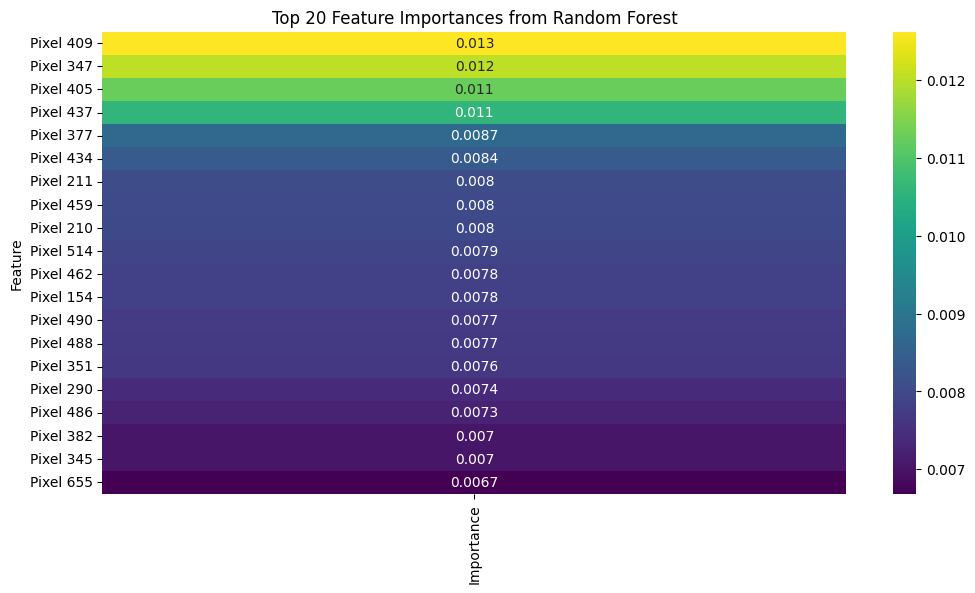

In [10]:
# Your code here
import seaborn as sns

feature_importances = rf.feature_importances_
feature_names = [f"Pixel {i}" for i in range(X.shape[1])]
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
})
plt.figure(figsize=(12, 6))
sns.heatmap(importance_df.sort_values("Importance", ascending=False).head(20).set_index("Feature"), annot=True, cmap="viridis")
plt.xticks(rotation=90)
plt.title("Top 20 Feature Importances from Random Forest")
plt.show()